# Clientes com alto volume de tickets no AgriManager

Pedido do time de desenvolvimento: descobrir quais clientes abrem muitos tickets, por que abrem e
quais merecem atenção prioritária. O resultado alimenta a planilha
`analise-tickets-clientes.xlsx`, onde o CS marca a prioridade de cada cliente.

**Bases** (pasta `dados/`):
- `Analise de tickets abertos.xlsx`: tickets do AgriManager de jan/2025 a set/2026
- `Lista de Clientes.xlsx`: contratos da vertical produtor rural, com valor mensal e situação

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

In [2]:
COR_PRIMARIA   = "#0072B2"
COR_SECUNDARIA = "#94A3B8"
COR_DESTAQUE   = "#D55E00"
PALETA = ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#56B4E9", "#D55E00"]

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 110,
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.prop_cycle": plt.cycler(color=PALETA),
})

def reais(v):
    return f"R$ {v:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

## As duas bases foram lidas corretamente?
Checagem de tamanho, tipos e primeiras linhas antes de qualquer conta.

In [3]:
tickets = pd.read_excel("dados/Analise de tickets abertos.xlsx")
contratos = pd.read_excel("dados/Lista de Clientes.xlsx")
tickets.shape, contratos.shape

((20587, 27), (796, 18))

In [4]:
tickets.head(3)

,Ticket,Prioridade,Produto,Squad,Tipo,Abertura,Resolução,Fechamento,SLA,Curva,ID Grupo Econômico,Grupo Econônomico,Vertical,Status,Departamento,Agente,Categoria,Motivo,Causa,Necessidade,Justificativa,Avaliação,tags,2° Nível Serviço,3° Nível Serviço,4° Nível Serviço,Assunto
0,621482,Baixa,SIAGRI AGRIMANAGER,BDS AGM | SUPORTE N2,Público,2025-05-21,2025-05-28,2025-05-28,2025-06-02 11:35:45.693,A,10000655,AGROJEM - MIRANORTE-TO,PRODUTOR RURAL,Fechado,SUPORTE BDS AGM,IVAN ALVES DE JESUS JUNIOR,Dúvida,Apoio processos operacionais,NaN,NaN,NaN,NaN,"[""1 notificação - PMO"",""2 notificação - PMO"",""...",SERVIÇOS ALIARE,BDS005 - ATUALIZACAO DO SISTEMA AGM,NaN,Atualização do ERP Agrimanager - Versão 7.6.0.30
1,600966,Média,SIAGRI AGRIMANAGER,SUPORTE AGM | LEGISLAÇÃO | N1,Público,2025-03-19,2025-03-28,2025-03-28,2025-04-02 08:58:18.907,D,30000067,CAPIVARY AGRO PASTORIL - GOIANIA-GO,PRODUTOR RURAL,Fechado,SUPORTE AGM,LIVIA BARBOSA PAULA GRIZOLIA,Dúvida,Apoio processos operacionais,NaN,NaN,NaN,NaN,"[""1 notificação - PMO"",""2 notificação - PMO"",""...",ATENDIMENTO AO CLIENTE,CONTROLADORIA,INVENTARIOS - INVENTÁRIOS,SPED Fiscal - Registro H005 esta indo zerado.
2,760468,Média,SIAGRI AGRIMANAGER,DESENVOLVIMENTO | PRODUTO | AGRIMANAGER,Público,2026-05-14,NaT,NaT,NaT,C,10000448,MORINAGA - BRASILIA-DF (ADMINISTRACAO),PRODUTOR RURAL,Pausado,PRODUTO AGM,NaN,Adequação,NaN,NaN,Melhoria,Reaberto,Péssimo,"[""1 notificação - PMO"",""2 notificação - PMO"",""...",ATENDIMENTO AO CLIENTE,BENEFICIAMENTO DE SEMENTES,GERATERMOCONFORMIDADE - TERMO DE CONFORMIDADE,Duvida sobre o Termo de Conformidade - Gerar o...


In [5]:
contratos.tail(4)

,COD_CLIENTE,CLIENTE,CODI_GRUPO,NOME_GRUPO,VALOR_CONTRATO,CIDADE,CODI_EMP,CONTRATO,CPF_CNPJ,CURVA,GERENTE_CONTA,AGENTE_RELACIONAMENTO,DATA_CONTRATO,ESTADO,PERIODICIDADE,PRODUTO,SEGMENTO_PRINCIPAL,SITUACAO_CONTRATO
792,10000501,JUPARANA COMERCIAL AGRICOLA LTDA,10000119.0,JUPARANA - PARAGOMINAS-PA,5.086200e+02,PARAGOMINAS,1.0,10000036.0,2.219378e+12,A,LUILA LIMA,GABRIEL HENRIQUE DA SILVA DE OLIVEIRA,2005-06-18,PA,1.0,AGRIMANAGER ERP,DISTRIBUIDOR DE INSUMOS,ATIVO
793,Total,NaN,NaN,NaN,1.703707e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN
794,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN
795,Filtros aplicados:\nBU é PRODUTORES AGRICOLAS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN


**Resultado:** as duas bases foram lidas sem problema de acento, data ou número. A lista de
contratos traz 3 linhas de rodapé do relatório de origem ("Total" e filtros aplicados), que
precisam sair antes de qualquer soma.

## Quais tickets entram na análise?
Ficam só os tickets abertos pelo próprio cliente: saem os internos, os cancelados e as
pesquisas de satisfação (que são registros internos, não pedidos do cliente).

In [6]:
contratos = contratos[contratos["CONTRATO"].notna()].copy()

entra = (
    (tickets["Tipo"] == "Público")
    & (tickets["Status"] != "Cancelado")
    & (tickets["Categoria"] != "Pesquisa Satisfação")
)
tk = tickets[entra].copy()
len(contratos), len(tickets), len(tk)

(793, 20587, 19150)

## Por que os clientes abrem ticket?
A coluna "Categoria" sozinha esconde o motivo: "Problema" mistura erro do sistema com erro de uso
e configuração. Por isso "Problema" é separado pela coluna "Causa", e "Adequação" pela coluna
"Necessidade" (melhoria de produto x exigência legal).

In [7]:
ERRO_PRODUTO = "Erro de produto"
CATEGORIAS = [
    ERRO_PRODUTO, "Problema de configuração", "Erro de uso", "Externo ou sem causa definida",
    "Dúvida", "Melhoria no produto", "Adequação à legislação", "Solicitação de serviço",
]

def categoria_analise(linha):
    cat, causa, nec = linha["Categoria"], linha["Causa"], linha["Necessidade"]
    if cat in ("Bug", "Solução de contorno"):
        return ERRO_PRODUTO
    if cat == "Problema":
        if isinstance(causa, str) and causa.startswith("Bug no Produto"):
            return ERRO_PRODUTO
        return {"Configuração": "Problema de configuração",
                "Erro operacional": "Erro de uso"}.get(causa, "Externo ou sem causa definida")
    if cat == "Adequação":
        return "Adequação à legislação" if nec == "Legislação" else "Melhoria no produto"
    return {"Dúvida": "Dúvida", "Solicitação de serviço": "Solicitação de serviço"}.get(cat, "Sem categoria")

tk["categoria_analise"] = tk.apply(categoria_analise, axis=1)
tk[["Categoria", "Causa", "Necessidade", "categoria_analise"]].drop_duplicates().sort_values("categoria_analise")

,Categoria,Causa,Necessidade,categoria_analise
158,Adequação,NaN,Legislação,Adequação à legislação
0,Dúvida,NaN,NaN,Dúvida
5990,Dúvida,NaN,Legislação,Dúvida
6714,Solução de contorno,NaN,Melhoria,Erro de produto
133,Solução de contorno,NaN,NaN,Erro de produto
99,Bug,NaN,NaN,Erro de produto
75,Problema,Bug no Produto / ERP,NaN,Erro de produto
11706,Problema,Bug no Produto / ERP (não Utilizar),NaN,Erro de produto
23,Problema,Erro operacional,NaN,Erro de uso
89,Problema,Resolvido pelo usuário,NaN,Externo ou sem causa definida


In [8]:
motivos = tk["categoria_analise"].value_counts().to_frame("tickets")
motivos["% do total"] = (motivos["tickets"] / motivos["tickets"].sum() * 100).round(1)
motivos

,tickets,% do total
categoria_analise,,
Dúvida,9166,47.9
Problema de configuração,2785,14.5
Erro de uso,2425,12.7
Externo ou sem causa definida,1506,7.9
Erro de produto,1358,7.1
Solicitação de serviço,1064,5.6
Melhoria no produto,691,3.6
Adequação à legislação,155,0.8


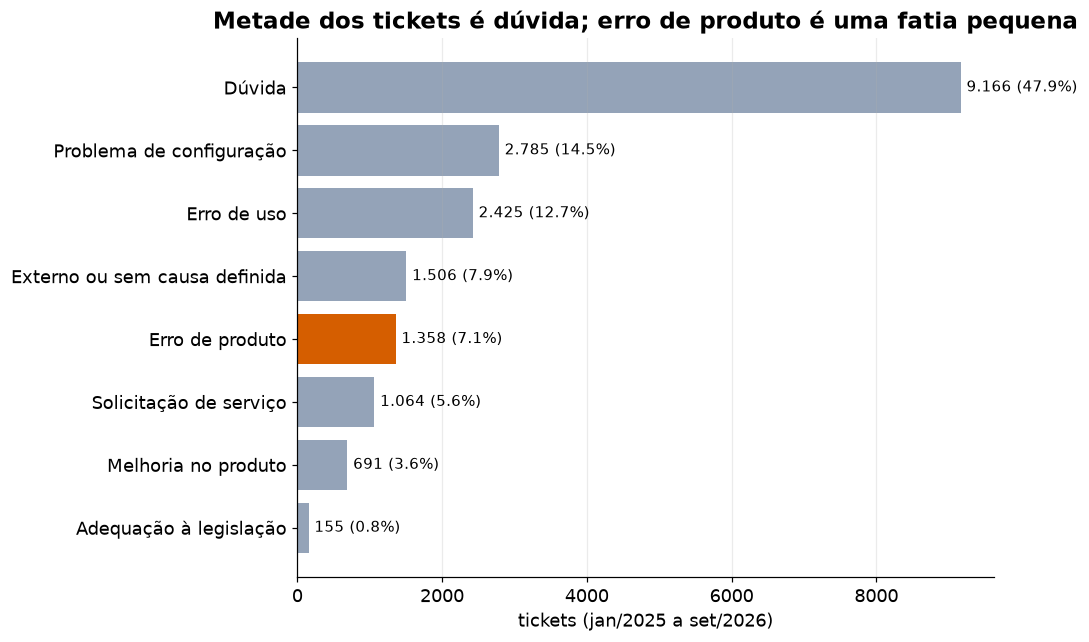

In [9]:
fig, ax = plt.subplots()
m = motivos.sort_values("tickets")
cores = [COR_DESTAQUE if i == ERRO_PRODUTO else COR_SECUNDARIA for i in m.index]
ax.barh(m.index, m["tickets"], color=cores)
for y, (v, p) in enumerate(zip(m["tickets"], m["% do total"])):
    ax.text(v + 80, y, f"{v:,} ({p}%)".replace(",", "."), va="center", fontsize=10)
ax.set_title("Metade dos tickets é dúvida; erro de produto é uma fatia pequena")
ax.set_xlabel("tickets (jan/2025 a set/2026)")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

**Resultado:** perto de 3 em cada 4 tickets vêm de uso do sistema (dúvida, configuração, erro de
uso), não de defeito. Erro de produto, que é o que o desenvolvimento resolve, é uma fatia pequena
do volume. Então "cliente que abre muito ticket" e "cliente com muito erro de produto" tendem a
ser listas diferentes: a primeira é assunto de CS e treinamento, a segunda de desenvolvimento.

## Quanto paga cada cliente que abre ticket?
O cruzamento é pelo código do grupo econômico. O valor pago é a soma mensal dos contratos
**ativos** do grupo, em todos os produtos (é o que o cliente representa pra Aliare).

In [10]:
contratos["CODI_GRUPO"] = contratos["CODI_GRUPO"].astype("Int64")
ativos = contratos[contratos["SITUACAO_CONTRATO"] == "ATIVO"]
valor = ativos.groupby("CODI_GRUPO")["VALOR_CONTRATO"].sum().rename("valor_mensal")

por_cliente = (
    tk.pivot_table(index="ID Grupo Econômico", columns="categoria_analise",
                   values="Ticket", aggfunc="count", fill_value=0)
    .reindex(columns=CATEGORIAS, fill_value=0)
)
por_cliente["total"] = por_cliente.sum(axis=1)
por_cliente = por_cliente.join(valor, how="left")
por_cliente["na_lista"] = por_cliente.index.isin(contratos["CODI_GRUPO"].dropna())
por_cliente["valor_mensal"] = por_cliente["valor_mensal"].fillna(0)
por_cliente[["total", ERRO_PRODUTO, "valor_mensal", "na_lista"]].head()

,total,Erro de produto,valor_mensal,na_lista
ID Grupo Econômico,,,,
10000004,1,0,0.00,True
10000005,66,2,0.00,True
10000006,20,0,2057.91,True
10000007,76,11,669.11,True
10000012,121,10,8427.66,True


In [11]:
pd.DataFrame({
    "clientes": [len(por_cliente), por_cliente["na_lista"].sum(), (por_cliente["valor_mensal"] > 0).sum()],
    "tickets": [por_cliente["total"].sum(),
                por_cliente.loc[por_cliente["na_lista"], "total"].sum(),
                por_cliente.loc[por_cliente["valor_mensal"] > 0, "total"].sum()],
}, index=["com ticket", "encontrados na lista", "com contrato ativo pagando"])

,clientes,tickets
com ticket,266,19150
encontrados na lista,226,18695
com contrato ativo pagando,203,17870


In [12]:
pagantes = por_cliente[por_cliente["valor_mensal"] > 0]
pagantes["valor_mensal"].describe().to_frame().T

,count,mean,std,min,25%,50%,75%,max
valor_mensal,203.0,5124.731035,4336.81884,264.44,2357.1351,3785.0,6441.08,30358.78


## Quem paga mais abre mais ticket?
Se valor e volume andarem juntos, o score vai repetir a mesma informação duas vezes. Correlação
por posição (Spearman), que não se deixa levar por um cliente extremo.

In [13]:
corr = pagantes[["valor_mensal", "total", ERRO_PRODUTO]].corr(method="spearman").round(2)
corr

,valor_mensal,total,Erro de produto
valor_mensal,1.00,0.55,0.50
total,0.55,1.00,0.77
Erro de produto,0.50,0.77,1.00


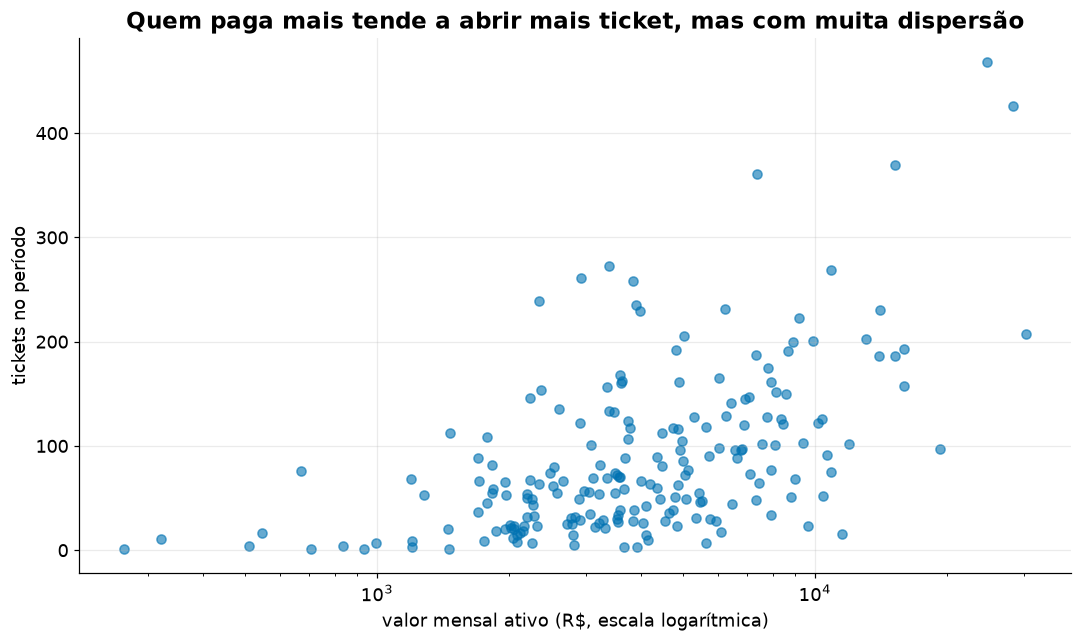

In [14]:
fig, ax = plt.subplots()
ax.scatter(pagantes["valor_mensal"], pagantes["total"], alpha=0.6, color=COR_PRIMARIA)
ax.set_xscale("log")
ax.set_title("Quem paga mais tende a abrir mais ticket, mas com muita dispersão")
ax.set_xlabel("valor mensal ativo (R$, escala logarítmica)")
ax.set_ylabel("tickets no período")
plt.tight_layout()
plt.show()

**Resultado:** os clientes com contrato ativo concentram quase todo o volume. Os grupos sem
contrato ativo (cancelados, suspensos ou fora da lista) continuam na planilha com valor zero,
identificados pela situação. Valor, volume e erro andam juntos de forma moderada: cliente maior
tem mais operação e mais usuário, então abre mais ticket e esbarra em mais defeito. Por isso o
score, sozinho, favorece o cliente grande; um cliente pequeno com muito erro precisa de uma regra
própria pra não sumir da fila.

## Os erros de produto estão concentrados em poucos clientes?
Se poucos clientes concentram os erros, o desenvolvimento consegue atacar com foco.

In [15]:
erros = por_cliente[ERRO_PRODUTO].sort_values(ascending=False)
acum = erros.cumsum() / erros.sum()
pd.DataFrame({
    "clientes com algum erro": [(erros > 0).sum()],
    "top 10 concentram": [f"{acum.iloc[9]:.0%}"],
    "top 20 concentram": [f"{acum.iloc[19]:.0%}"],
    "top 50 concentram": [f"{acum.iloc[49]:.0%}"],
})

,clientes com algum erro,top 10 concentram,top 20 concentram,top 50 concentram
0,178,32%,45%,69%


In [16]:
nomes = tk.groupby("ID Grupo Econômico")["Grupo Econônomico"].agg(lambda s: s.value_counts().index[0])
top = por_cliente.join(nomes).nlargest(15, ERRO_PRODUTO)
top["% erro no total"] = (top[ERRO_PRODUTO] / top["total"] * 100).round(0)
top["valor"] = top["valor_mensal"].map(reais)
top[["Grupo Econônomico", ERRO_PRODUTO, "total", "% erro no total", "valor"]]

,Grupo Econônomico,Erro de produto,total,% erro no total,valor
ID Grupo Econômico,,,,,
10000131,FAZENDA TRES COQUEIROS - SAPEZAL-MT,89,369,24.0,"R$ 15.242,47"
10000130,GRUPO MIZOTE - BARREIRAS-BA,62,223,28.0,"R$ 9.202,70"
10000440,SEMENTES VITORIA - RIO VERDE-GO,47,261,18.0,"R$ 2.925,82"
10000663,FAZENDA MEDIANEIRA,40,239,17.0,"R$ 2.345,54"
10000142,GRUPO MICHELS - PORTELANDIA-GO,38,186,20.0,"R$ 14.006,63"
10000625,AGRICULTURA S EPP - LUIS EDUARDO MAGALHAES - BA,37,201,18.0,"R$ 9.870,70"
30000512,AGROMANTOVA - BALSAS - MA,36,468,8.0,"R$ 24.706,60"
10000655,AGROJEM - MIRANORTE-TO,32,426,8.0,"R$ 28.246,03"
30000116,FAZENDAS LR KONAGESKI - DIAMANTINO-MT,28,361,8.0,"R$ 7.373,65"


## Em quais partes do sistema estão os erros de produto?
O "4º nível de serviço" do ticket indica a tela ou rotina do AgriManager.

In [17]:
ep = tk[tk["categoria_analise"] == ERRO_PRODUTO]
modulos = ep["4° Nível Serviço"].fillna("(não informado)").value_counts()
modulos.head(12).to_frame("erros de produto")

,erros de produto
4° Nível Serviço,
FMIMPORTAXML - IMPORTAÇÃO DE XML,91
DOCUMENTOS - MOVIMENTO DE DOCUMENTOS,53
FECHAADIANTAMENTO - FECHAMENTO DE ADIANTAMENTO,43
LANCCONTAB - LANÇAMENTOS CONTÁBEIS,39
NFEMANAGER - GERENCIAMENTO DA NF-E,34
GERAINFFISCAIS - ESCRITURAÇÃO FISCAL DIGITAL (EFD),32
NF - EMISSÃO DE NOTAS FISCAIS,31
USOMODULOS - SERVIDOR DE APLICAÇÃO - ERP AGRIMANAGER,30
MOVCONTAS - MOVIMENTAÇÃO FINANCEIRA,29


In [18]:
ep["3° Nível Serviço"].fillna("(não informado)").value_counts().head(8).to_frame("erros de produto")

,erros de produto
3° Nível Serviço,
ADMINISTRATIVO/FINANCEIRO,767
CONTROLADORIA,182
ARMAZENAGEM,156
FAZENDAS E LAVOURAS,115
ALGODOEIRA,106
BENEFICIAMENTO DE SEMENTES,27
RECURSOS HUMANOS,3
MAPAS,1


In [19]:
em_aberto = ~tk["Status"].isin(["Fechado", "Resolvido", "Cancelado"])
pd.crosstab(tk["categoria_analise"], em_aberto).rename(columns={False: "encerrados", True: "em aberto hoje"})

Status,encerrados,em aberto hoje
categoria_analise,,
Adequação à legislação,75,80
Dúvida,9138,28
Erro de produto,1227,131
Erro de uso,2421,4
Externo ou sem causa definida,1493,13
Melhoria no produto,360,331
Problema de configuração,2779,6
Solicitação de serviço,1027,37


**Resultado:** [Certo] os erros de produto não se concentram num punhado de clientes: os 10
primeiros somam cerca de um terço. [Provável] o defeito está mais nas rotinas do sistema do que em
clientes específicos: importação de XML, movimento de documentos e fechamento de adiantamento
lideram, e a área administrativa/financeira responde por mais da metade dos erros. Corrigir essas
rotinas atende muitos clientes de uma vez.

Dois perfis aparecem no topo: clientes em que o defeito pesa muito no total (cerca de 1 em cada
4 tickets é erro de produto) e clientes grandes que lideram em volume, mas com erro baixo (8%),
em que o volume é de uso. Metade das melhorias e das adequações legais segue em aberto, além de
131 erros de produto: é a fila que o desenvolvimento já carrega.

## Como fica o score de cada cliente?
Pesos definidos com o Julio: **valor pago 40%, erros de produto 40%, volume total de tickets 20%**.
Cada item vira uma posição relativa de 0 a 1 entre os clientes (percentil), pra que um cliente
extremo não achate os outros. É a mesma conta que a planilha faz com a função PERCENTRANK.

In [20]:
PESOS = {"valor_mensal": 0.40, ERRO_PRODUTO: 0.40, "total": 0.20}

def percentil(s):
    menores = s.apply(lambda x: (s < x).sum())
    return menores / (len(s) - 1)

pct = pd.DataFrame({col: percentil(por_cliente[col]) for col in PESOS})
por_cliente["score"] = sum(pct[col] * peso for col, peso in PESOS.items()) * 100
por_cliente["pct_erro"] = pct[ERRO_PRODUTO]
por_cliente["score"].describe().round(1).to_frame().T

,count,mean,std,min,25%,50%,75%,max
score,266.0,45.7,29.3,0.0,19.7,47.5,69.8,98.9


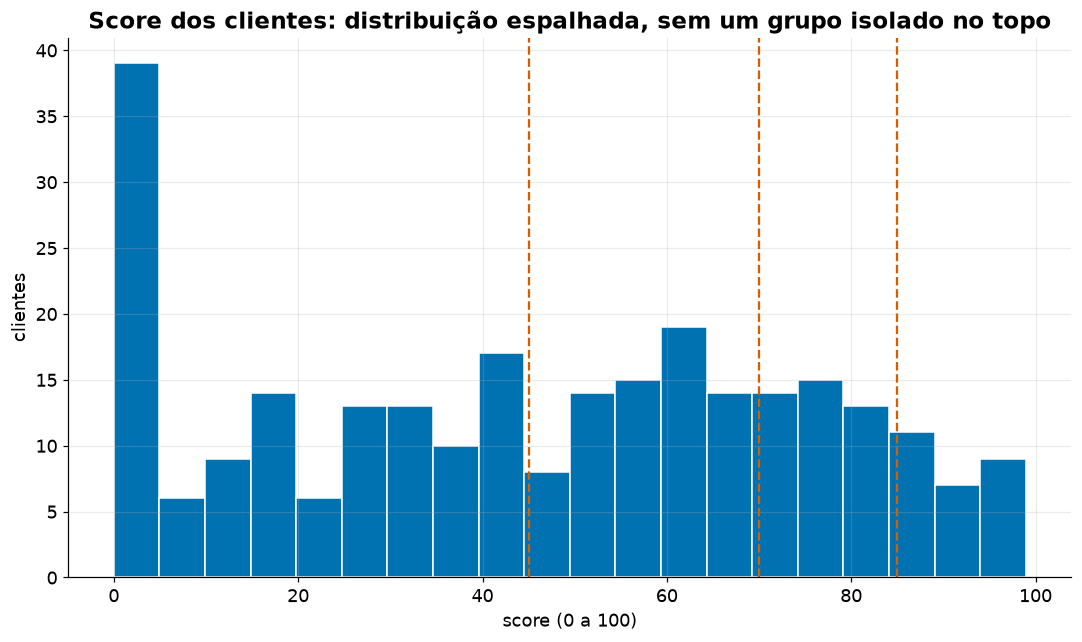

In [21]:
fig, ax = plt.subplots()
ax.hist(por_cliente["score"], bins=20, color=COR_PRIMARIA, edgecolor="white")
for corte in (45, 70, 85):
    ax.axvline(corte, color=COR_DESTAQUE, linestyle="--")
ax.set_title("Score dos clientes: distribuição espalhada, sem um grupo isolado no topo")
ax.set_xlabel("score (0 a 100)")
ax.set_ylabel("clientes")
plt.tight_layout()
plt.show()

**Resultado:** como o score é feito de posições relativas, os clientes se espalham de 0 a 100 sem
um bloco isolado no topo. Os cortes de urgência são, então, uma escolha de quantos clientes cabem
na fila, não uma fronteira natural dos dados.

## Quantos clientes caem em cada nível de urgência?
Os cortes foram calibrados pra que "Crítica" fique perto dos 10% do topo. **Crítica** a partir de
85 pontos; **Alta** a partir de 70 **ou** quando o cliente está entre os 10% com mais erros de
produto (muito erro é urgência alta mesmo em cliente menor); **Média** a partir de 45; abaixo
disso, **Baixa**.

In [22]:
def urgencia(linha):
    if linha["score"] >= 85:
        return "Crítica"
    if linha["score"] >= 70 or linha["pct_erro"] >= 0.9:
        return "Alta"
    return "Média" if linha["score"] >= 45 else "Baixa"

por_cliente["urgencia"] = por_cliente.apply(urgencia, axis=1)
por_cliente["urgencia"].value_counts().reindex(["Crítica", "Alta", "Média", "Baixa"]).to_frame("clientes")

,clientes
urgencia,
Crítica,25
Alta,40
Média,74
Baixa,127


In [23]:
subiu = por_cliente[(por_cliente["urgencia"] == "Alta") & (por_cliente["score"] < 70)]
subiu.join(nomes)[["Grupo Econônomico", ERRO_PRODUTO, "total", "valor_mensal", "score"]].round(1)

,Grupo Econônomico,Erro de produto,total,valor_mensal,score
ID Grupo Econômico,,,,,


**Resultado:** [Certo] a regra de erro não muda o nível de ninguém hoje: todo cliente entre os
10% com mais erro de produto já passa de 70 pontos, porque erro anda junto com volume. A regra
fica na planilha como garantia, caso os pesos mudem (por exemplo, se o valor pago ganhar mais
peso).

In [24]:
ranking = por_cliente.join(nomes).sort_values("score", ascending=False)
ranking["valor"] = ranking["valor_mensal"].map(reais)
ranking[["Grupo Econônomico", "valor", ERRO_PRODUTO, "total", "score", "urgencia"]].head(15).round(1)

,Grupo Econônomico,valor,Erro de produto,total,score,urgencia
ID Grupo Econômico,,,,,,
10000131,FAZENDA TRES COQUEIROS - SAPEZAL-MT,"R$ 15.242,47",89,369,98.9,Crítica
30000512,AGROMANTOVA - BALSAS - MA,"R$ 24.706,60",36,468,98.8,Crítica
10000655,AGROJEM - MIRANORTE-TO,"R$ 28.246,03",32,426,98.7,Crítica
10000142,GRUPO MICHELS - PORTELANDIA-GO,"R$ 14.006,63",38,186,96.2,Crítica
30000225,LAZAROTTO AGRONEGOCIOS - TAPURAH - MT,"R$ 13.056,63",24,202,95.8,Crítica
30000319,OGAWA AGRO - NOVA ROSALANDIA - TO,"R$ 15.997,59",17,193,95.7,Crítica
10000130,GRUPO MIZOTE - BARREIRAS-BA,"R$ 9.202,70",62,223,95.5,Crítica
10000625,AGRICULTURA S EPP - LUIS EDUARDO MAGALHAES - BA,"R$ 9.870,70",37,201,95.1,Crítica
10000668,FAZENDA POTRICH - SORRISO-MT,"R$ 15.992,55",17,157,94.6,Crítica


**Resultado:** o topo mistura os dois perfis vistos antes. Um cliente lidera pelos dois lados
(valor alto e o maior número de erros de produto). Outros estão no topo por valor e volume, com
erro baixo: pra esses a ação é mais de CS que de desenvolvimento. E há os que entram pelo erro.
A coluna "categoria predominante" da planilha ajuda o CS a separar esses casos na hora de marcar
a prioridade.

## O tipo de ticket que o cliente mais abre diferencia os clientes?
A ideia era colorir cada cliente pela categoria que ele mais abre. Antes, vale ver se essa cor
separa alguém.

In [25]:
predominante = por_cliente[CATEGORIAS].idxmax(axis=1)
predominante.value_counts().to_frame("clientes")

,clientes
Dúvida,233
Solicitação de serviço,18
Problema de configuração,9
Melhoria no produto,2
Erro de produto,2
Externo ou sem causa definida,2


**Resultado:** [Certo] quase todo cliente tem "Dúvida" como categoria predominante, porque dúvida
é metade de toda a base. A cor pela categoria predominante pintaria quase tudo igual. Faz mais
sentido olhar em que tipo de ticket o cliente **foge da média**.

## Em que tipo de ticket cada cliente foge da média?
Para cada cliente e categoria: participação da categoria nos tickets do cliente dividida pela
participação dela na base toda. Só vale com pelo menos 5 tickets no tipo (pra não destacar
cliente por 1 ou 2 tickets) e a partir de 1,5 vez a média.

In [26]:
media_base = por_cliente[CATEGORIAS].sum() / por_cliente["total"].sum()
fator = por_cliente[CATEGORIAS].div(por_cliente["total"], axis=0).div(media_base, axis=1)
fator = fator.where(por_cliente[CATEGORIAS] >= 5, 0)
por_cliente["destaque"] = fator.idxmax(axis=1).where(fator.max(axis=1) >= 1.5, "Perfil na média")
por_cliente["vezes_media"] = fator.max(axis=1).round(1)
por_cliente["destaque"].value_counts().to_frame("clientes")

,clientes
destaque,
Perfil na média,132
Solicitação de serviço,24
Externo ou sem causa definida,23
Problema de configuração,21
Erro de produto,20
Erro de uso,16
Melhoria no produto,13
Dúvida,12
Adequação à legislação,5


In [27]:
ranking = por_cliente.join(nomes).sort_values("score", ascending=False)
ranking[["Grupo Econônomico", "score", "urgencia", "destaque", "vezes_media"]].head(10).round(1)

,Grupo Econônomico,score,urgencia,destaque,vezes_media
ID Grupo Econômico,,,,,
10000131,FAZENDA TRES COQUEIROS - SAPEZAL-MT,98.9,Crítica,Erro de produto,3.4
30000512,AGROMANTOVA - BALSAS - MA,98.8,Crítica,Melhoria no produto,1.7
10000655,AGROJEM - MIRANORTE-TO,98.7,Crítica,Perfil na média,1.4
10000142,GRUPO MICHELS - PORTELANDIA-GO,96.2,Crítica,Adequação à legislação,5.3
30000225,LAZAROTTO AGRONEGOCIOS - TAPURAH - MT,95.8,Crítica,Melhoria no produto,2.2
30000319,OGAWA AGRO - NOVA ROSALANDIA - TO,95.7,Crítica,Solicitação de serviço,1.7
10000130,GRUPO MIZOTE - BARREIRAS-BA,95.5,Crítica,Erro de produto,3.9
10000625,AGRICULTURA S EPP - LUIS EDUARDO MAGALHAES - BA,95.1,Crítica,Erro de produto,2.6
10000668,FAZENDA POTRICH - SORRISO-MT,94.6,Crítica,Solicitação de serviço,1.7


**Resultado:** [Certo] com esse critério, metade dos clientes ganha um destaque, espalhado pelas oito
categorias, e o topo da fila passa a mostrar perfis diferentes: clientes com erro de produto
3 a 4 vezes acima da média, clientes que puxam melhoria de produto, clientes com exigência legal
bem acima do normal. [Provável] para o desenvolvimento, os clientes críticos com destaque em
erro de produto ou melhoria são o primeiro recorte; os críticos com destaque em dúvida,
configuração ou erro de uso são assunto de CS e treinamento. A planilha mostra as duas colunas
(predominante e em destaque), cada uma com a cor da categoria.

## Conclusões

- **Por que o cliente abre ticket:** quase 3 em cada 4 tickets vêm de uso do sistema (dúvida,
  configuração, erro de uso). Erro de produto é 7% do volume. Volume alto de ticket é, na maior
  parte, assunto de CS e treinamento.
- **Onde está o defeito:** os erros de produto estão espalhados por 178 clientes. O esforço do
  desenvolvimento rende mais nas rotinas (importação de XML, movimento de documentos, fechamento
  de adiantamento, lançamentos contábeis; área administrativa/financeira) do que em clientes
  isolados.
- **Fila que já existe:** metade das melhorias e das adequações legais, e 131 erros de produto,
  seguem em aberto.
- **Score (valor 40%, erro 40%, volume 20%):** 25 clientes em urgência crítica e 40 em alta. O
  topo mistura clientes de alto valor com uso intenso e clientes com muito defeito.
- **Cor por cliente:** a categoria que o cliente mais abre é "Dúvida" em quase todos; o que
  diferencia é a categoria em que ele foge da média (metade dos clientes tem um destaque).
- **Planilha:** `analise-tickets-clientes.xlsx` traz o score por cliente com categoria
  predominante e em destaque, uma aba por categoria de ticket, a base cruzada e a fila de
  atendimento, que se reordena quando o CS marca "Sim" em "Prioridade CS".